In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samithsachidanandan/world-happiness-report-2020-2024")

print("Path to dataset files:", path)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
# Load the dataset
file_path = r"C:\Users\HP\.cache\kagglehub\datasets\samithsachidanandan\world-happiness-report-2020-2024\versions\3\2020.csv"
df = pd.read_csv(file_path)

In [2]:
df.info()
df.head()   
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  153 non-null    str    
 1   Happiness Rank                153 non-null    int64  
 2   Happiness score               153 non-null    float64
 3   Upperwhisker                  153 non-null    float64
 4   Lowerwhisker                  153 non-null    float64
 5   Economy (GDP per Capita)	     153 non-null    float64
 6   Social support                153 non-null    float64
 7   Healthy life expectancy       153 non-null    float64
 8   Freedom to make life choices  153 non-null    float64
 9   Generosity                    153 non-null    float64
 10  Perceptions of corruption     153 non-null    float64
dtypes: float64(9), int64(1), str(1)
memory usage: 13.3 KB


,Happiness Rank,Happiness score,Upperwhisker,Lowerwhisker,Economy (GDP per Capita)\t,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,5.473203,5.578431,5.368301,0.868889,1.155294,0.693072,0.463529,0.189542,0.130588
std,44.311398,1.112110,1.096647,1.128770,0.372560,0.287001,0.254189,0.140981,0.100094,0.113092
min,1.000000,2.570000,2.630000,2.510000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,4.720000,4.830000,4.600000,0.580000,0.990000,0.500000,0.380000,0.120000,0.060000
50%,77.000000,5.510000,5.610000,5.430000,0.920000,1.200000,0.760000,0.480000,0.180000,0.100000
75%,115.000000,6.230000,6.360000,6.140000,1.170000,1.390000,0.870000,0.580000,0.260000,0.160000
max,153.000000,7.810000,7.870000,7.750000,1.540000,1.550000,1.140000,0.690000,0.570000,0.530000


In [3]:

# Let's assume 'df' is your World Happiness dataframe
df = df.rename(columns={
    'Economy (GDP per Capita)\t': 'gdp_pc',
    'Social support': 'social_support',
    'Healthy life expectancy': 'life_exp',
    'Freedom to make life choices': 'freedom',
    'Perceptions of corruption': 'corruption',
})

# Pro-tip: Verify the change
print(df.columns)
df.isnull().sum()

Index(['Country name', 'Happiness Rank', 'Happiness score', 'Upperwhisker',
       'Lowerwhisker', 'gdp_pc', 'social_support', 'life_exp', 'freedom',
       'Generosity', 'corruption'],
      dtype='str')


Country name       0
Happiness Rank     0
Happiness score    0
Upperwhisker       0
Lowerwhisker       0
gdp_pc             0
social_support     0
life_exp           0
freedom            0
Generosity         0
corruption         0
dtype: int64

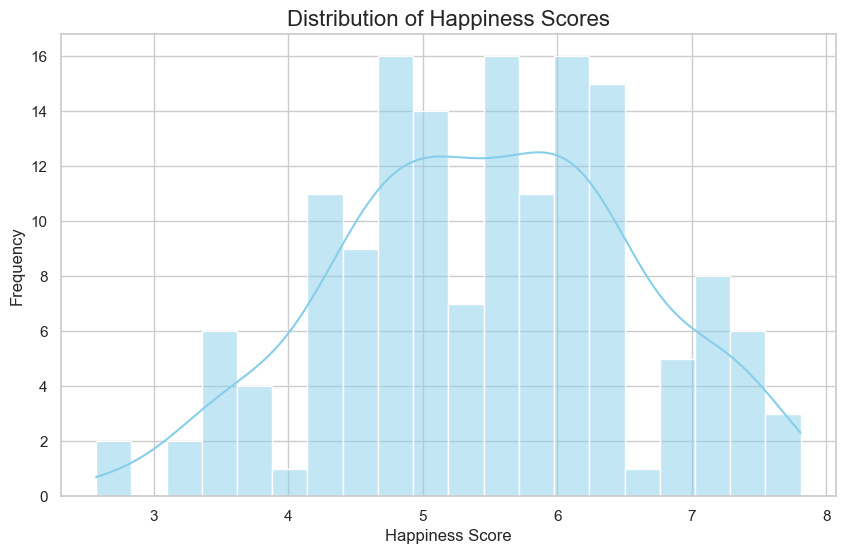

In [4]:
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Happiness score'], kde=True, color='skyblue', bins=20)

# Add titles and labels
plt.title('Distribution of Happiness Scores', fontsize=16)
plt.xlabel('Happiness Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show the plot
plt.show()

In [5]:
from scipy import stats

# If p-value > 0.05, the data is likely normal
stat, p = stats.shapiro(df['Happiness score'])
print(f'Statistics={stat:.3f}, p-value={p:.3f}')

Statistics=0.989, p-value=0.278


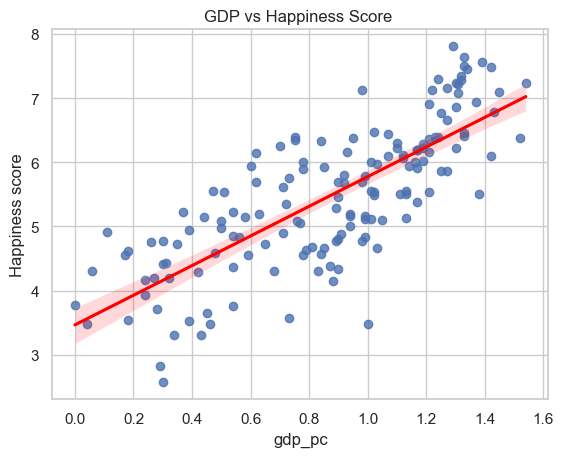

In [6]:
sns.regplot(data=df, x='gdp_pc', y='Happiness score', line_kws={"color": "red"})
plt.title('GDP vs Happiness Score ')
plt.show()

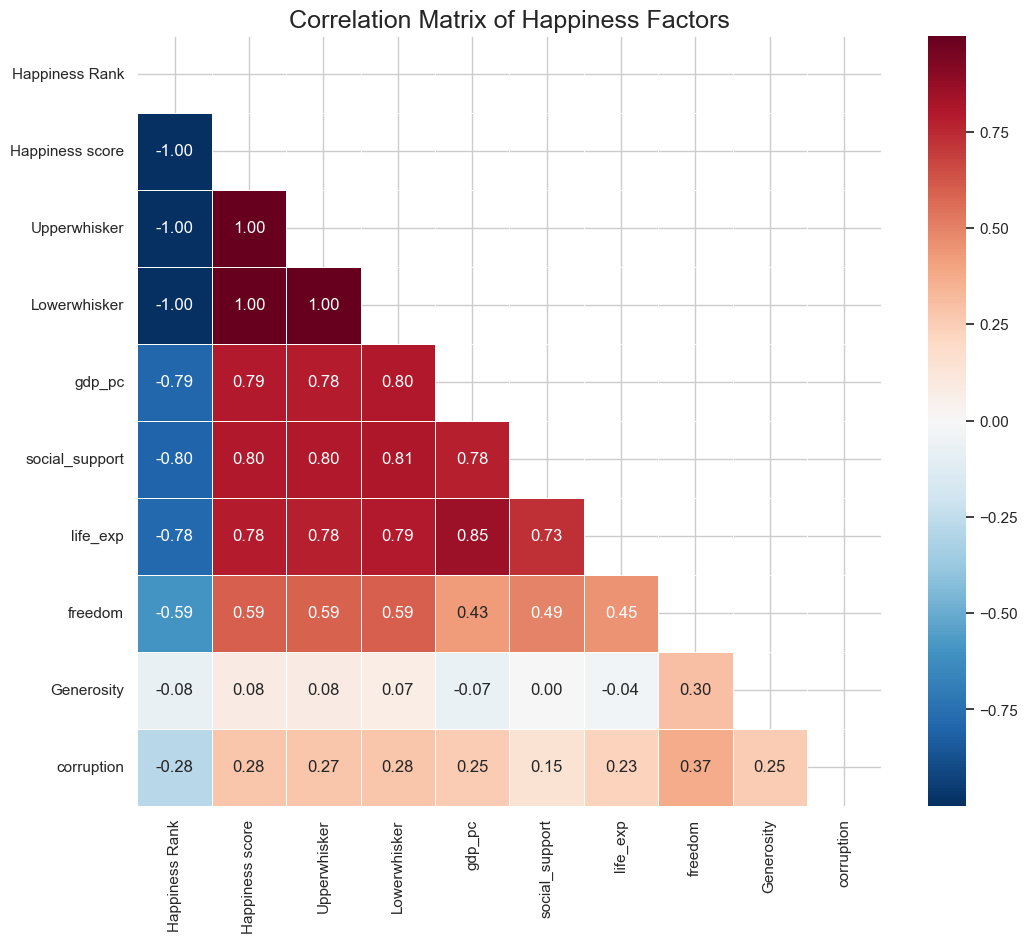

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter for numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate Spearman Correlation
corr_matrix = numeric_df.corr(method='spearman')

# 3. Create a mask to hide the upper triangle (optional but looks pro)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='RdBu_r', # Red for positive, Blue for negative
            center=0, 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Correlation Matrix of Happiness Factors', fontsize=18)
plt.show()

In [8]:
# Assuming 'df' is sorted by 'rank' (1 at the top)
top_10 = df.head(10)
bottom_10 = df.tail(10)

# Combine them into one temporary DataFrame for plotting
comparison_df = pd.concat([top_10, bottom_10])

C:\Users\HP\AppData\Local\Temp\ipykernel_20912\1663424936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=comparison_df, x='Happiness score', y='Country name', palette=colors)
C:\Users\HP\AppData\Local\Temp\ipykernel_20912\1663424936.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=comparison_df, x='gdp_pc', y='Country name', palette=colors)


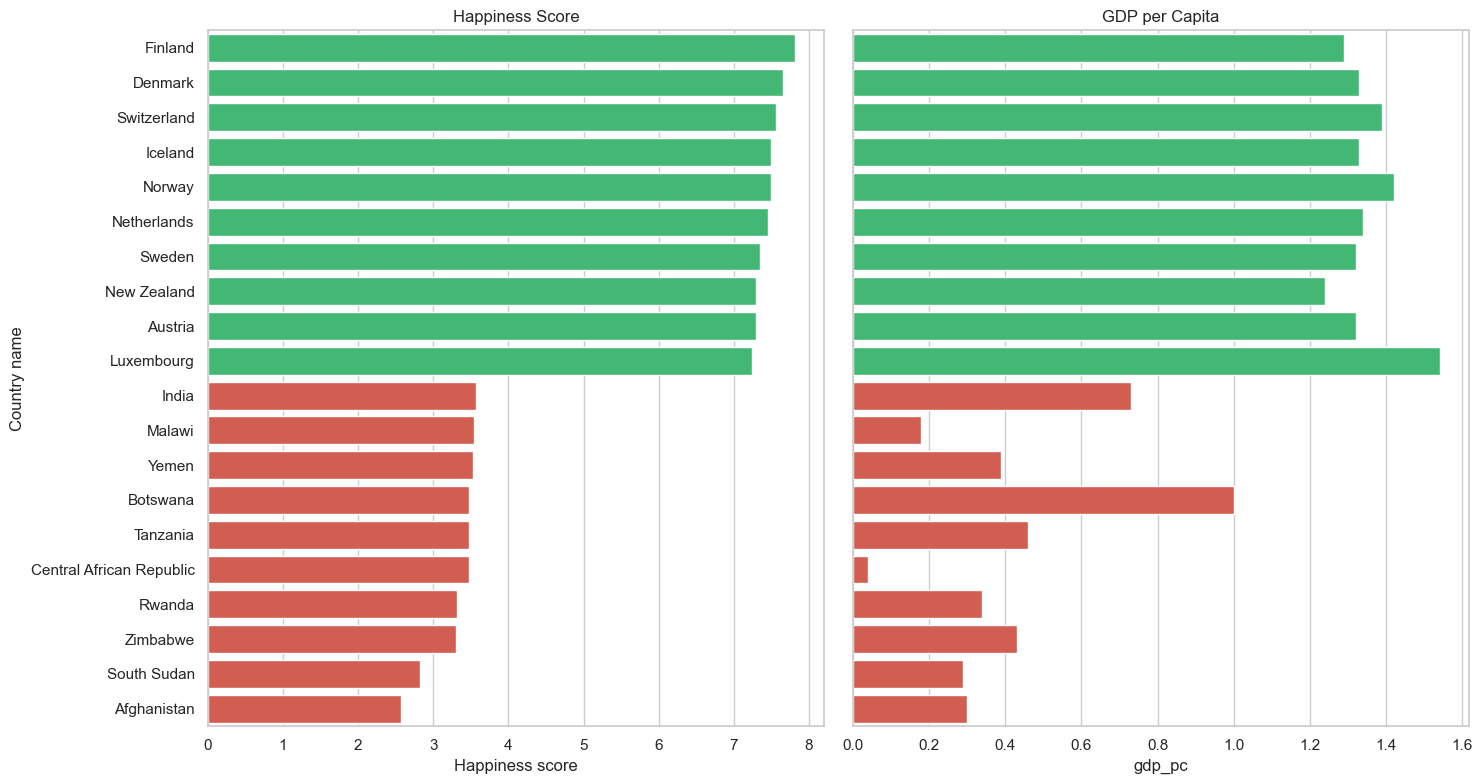

In [10]:
# Side-by-side comparison of Score vs GDP
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
colors = ["#2ecc71"] * 10 + ["#e74c3c"] * 10
sns.barplot(ax=axes[0], data=comparison_df, x='Happiness score', y='Country name', palette=colors)
axes[0].set_title('Happiness Score')

sns.barplot(ax=axes[1], data=comparison_df, x='gdp_pc', y='Country name', palette=colors)
axes[1].set_title('GDP per Capita')

plt.tight_layout()
plt.show()

In [11]:
import plotly.express as px

# Use the exact names from your error message
fig = px.choropleth(df, 
                    locations="Country name",      # Changed from "Country"
                    locationmode='country names',
                    color="Happiness score",      # Changed from "Score" to match your error
                    hover_name="Country name",     # Changed from "Country"
                    title="Global Happiness Levels (Interactive Map)",
                    color_continuous_scale=px.colors.sequential.Viridis)

fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20912\2218141318.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df,
